In [ ]:
import photometry as phot
import numpy as np
import matplotlib.pyplot as plt

'''
CHECKLIST FOR TESTING COLOR CODE:
=================================
[x] Are planet spectra reading in properly?
[x] Does stellar spectrum read in properly?
[x] Does function to read in filter transmission work?
[x] Does color calculation function work?
[ ] Convert from color / flux per band to counts
[ ] Write a new script that calculates color, counts, and runs deconfuser
[ ] Pass counts through photometry model
[ ] 

'''

'\nCHECKLIST FOR TESTING COLOR CODE:\n=================================\n[x] Are planet spectra reading in properly?\n[x] Does stellar spectrum read in properly?\n[x] Does function to read in filter transmission work?\n[ ] Does color calculation function work?\n[ ] Convert from color / flux per band to counts\n[ ] Pass couunts through photometry model\n[ ] \n\n'

In [2]:
mu_sun = 4*np.pi**2
system = phot.System(n_exozodi=4/3600, n_leakage=20/3600, n_zodi=2/3600) # background count contributions in units of s^-1
star = phot.Star(T=5778, R_star=695700e3, d_system=10, mu=mu_sun) # system distance in parsecs -- values for the Sun
planet1 = phot.Planet(R_p=69911e3, Ag=0.5)                        # Rp = 6.371e6 km, Ag=0.3 <-- values for Earth
planet2 = phot.Planet(R_p=69911e3, Ag=0.5)                        # Rp = 6.371e6 km, Ag=0.3 <-- values for Earth

detector = phot.Detector(qe=0.9, cic=0.016, dark_current=5e-4, read_noise=120, gain=1000, # qe=0.837, dark_current=1.3e-4, read_noise=120
                    fwc=80000, conversion_gain=1.0, t=1.8e7, D=2, throughput=0.05, f_pa=0.87, # throughput=0.38, f_pa=0.039,
                    wavelength=500e-9, bandwidth=8e-9) 

In [3]:
albedo_file = "/Users/shasler/Documents/Projects/planet_modeling/Cahoy_et_al_2010_Albedo_Spectra/albedo_spectra/Jupiter_1x_0.8AU_0deg.dat"
albedo_file2 = "/Users/shasler/Documents/Projects/planet_modeling/Cahoy_et_al_2010_Albedo_Spectra/albedo_spectra/Jupiter_3x_10AU_0deg.dat"
stellar_file = "/Users/shasler/Documents/Projects/NH_ice_giants/other_data/solar_spec_ergcm2s.txt"
filter_file = "/Users/shasler/Documents/Projects/deconfusion_color/passbands/roman_filters.txt"

In [4]:
# initialize filter object
all_filters = phot.Filters(filter_file)
filter_data = all_filters.read_filter_curves()
filter_name1 = "575"
filter_name2 = "659"
filter_name3 = "729"

vis_lambda_range1 = all_filters.lambda_range(filter_name1, filter_data) # get wavelength range for filter
vis_lambda_range2 = all_filters.lambda_range(filter_name2, filter_data) 
vis_lambda_range3 = all_filters.lambda_range(filter_name3, filter_data)

In [5]:
# read in stellar and planet spectra
star_wavelength, star_spectrum = star.read_spectrum(stellar_file) # um, erg/cm^2/s/um
planet1_wavelength, planet1_spectrum = planet1.read_spectrum(albedo_file) # um, albedo
planet2_wavelength, planet2_spectrum = planet2.read_spectrum(albedo_file2) # um, albedo

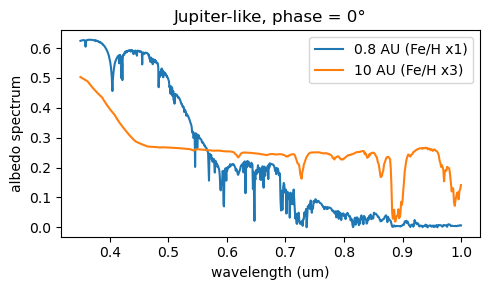

In [6]:
# Test spectra read-in with plots
fig, (ax1) = plt.subplots(1, 1, figsize=(5, 3), sharey=True)
ax1.plot(planet1_wavelength, planet1_spectrum, label='0.8 AU (Fe/H x1)')
ax1.plot(planet2_wavelength, planet2_spectrum, label='10 AU (Fe/H x3)')

ax1.set_xlabel("wavelength (um)")
ax1.set_ylabel("albedo spectrum")
ax1.set_title(f"Jupiter-like, phase = 0°")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
# Grab spectra in wavelength range of filter of interest
filt1_spec1, filt1_lambda1 = phot.spectrum_in_filter(planet1_wavelength, planet1_spectrum, vis_lambda_range1[0], vis_lambda_range1[1])
filt2_spec1, filt2_lambda1 = phot.spectrum_in_filter(planet1_wavelength, planet1_spectrum, vis_lambda_range2[0], vis_lambda_range2[1])
filt3_spec1, filt3_lambda1 = phot.spectrum_in_filter(planet1_wavelength, planet1_spectrum, vis_lambda_range3[0], vis_lambda_range3[1]) 

filt1_spec2, filt1_lambda2 = phot.spectrum_in_filter(planet2_wavelength, planet2_spectrum, vis_lambda_range1[0], vis_lambda_range1[1])
filt2_spec2, filt2_lambda2 = phot.spectrum_in_filter(planet2_wavelength, planet2_spectrum, vis_lambda_range2[0], vis_lambda_range2[1])
filt3_spec2, filt3_lambda2 = phot.spectrum_in_filter(planet2_wavelength, planet2_spectrum, vis_lambda_range3[0], vis_lambda_range3[1])

# Put star on planet wavelength grid
stellar_flux = star.interp_spectrum(planet1_wavelength) # interpolate stellar spectrum to planet wavelength grid

In [11]:
# Put throughput on wavelength grid for each filter
f1 = all_filters.filter_throughput(filter_name1, planet1_wavelength)
f2 = all_filters.filter_throughput(filter_name2, planet1_wavelength)
f3 = all_filters.filter_throughput(filter_name3, planet1_wavelength)

In [12]:
# Compuate color (integrals)
planet1_f1 = phot.compute_color(f1, planet1_spectrum, planet1_wavelength, stellar_flux)
planet1_f2 = phot.compute_color(f2, planet1_spectrum, planet1_wavelength, stellar_flux)
planet1_f3 = phot.compute_color(f3, planet1_spectrum, planet1_wavelength, stellar_flux)

planet2_f1 = phot.compute_color(f1, planet2_spectrum, planet2_wavelength, stellar_flux)
planet2_f2 = phot.compute_color(f2, planet2_spectrum, planet2_wavelength, stellar_flux)
planet2_f3 = phot.compute_color(f3, planet2_spectrum, planet2_wavelength, stellar_flux)

In [ ]:
# Color comparisons 
planet1_f1_f2 = phot.compare_bands(planet1_f1, planet1_f2)
planet1_f2_f3 = phot.compare_bands(planet1_f2, planet1_f3)

planet2_f1_f2 = phot.compare_bands(planet2_f1, planet2_f2)
planet2_f2_f3 = phot.compare_bands(planet2_f2, planet2_f3)

-0.09376199522349496

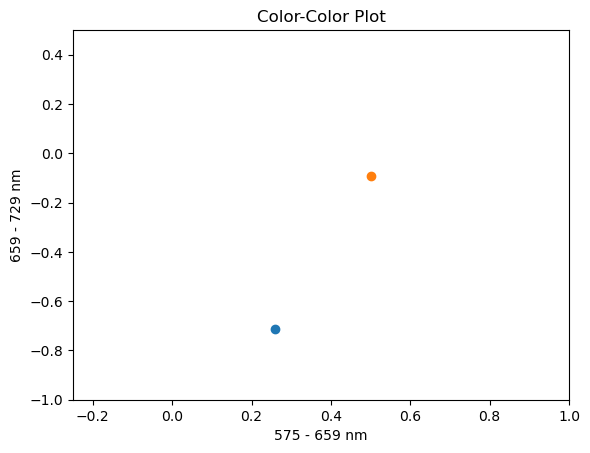

In [20]:
# Compare color values on color-color plot
plt.figure()
plt.scatter(planet1_f1_f2, planet1_f2_f3, label='planet 1')
plt.scatter(planet2_f1_f2, planet2_f2_f3, label='planet 2')
plt.xlabel(f"{filter_name1} - {filter_name2} nm")
plt.ylabel(f"{filter_name2} - {filter_name3} nm")
plt.title("Color-Color Plot")
plt.ylim(-1,0.5)
plt.xlim(-0.25, 1.0)
plt.show()